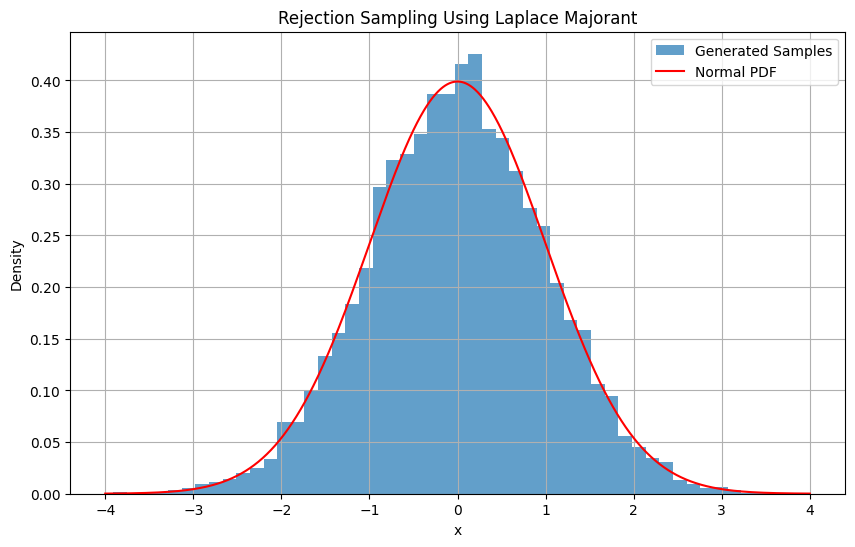

In [89]:
import numpy as np
import matplotlib.pyplot as plt

# Define target distribution (standard normal PDF)
def normal_pdf(x):
    return (1 / np.sqrt(2 * np.pi)) * np.exp(-x**2 / 2)

# Define Laplace proposal distribution
def laplace_pdf(x, lambda_):
    return (lambda_ / 2) * np.exp(-lambda_ * np.abs(x))

# Sampling from Laplace distribution
def sample_laplace(lambda_, size=1):
    U = np.random.uniform(0, 1, size)
    return np.sign(U - 0.5) * (-np.log(1 - 2 * np.abs(U - 0.5)) / lambda_)

# Rejection sampling
def rejection_sampling(normal_pdf, laplace_pdf, lambda_, M, n_samples):
    samples = []
    while len(samples) < n_samples:
        # Step 1: Draw candidate sample from Laplace distribution
        X = sample_laplace(lambda_, size=1)[0]

        # Step 2: Draw uniform random number for acceptance
        U = np.random.uniform(0, 1)

        # Step 3: Accept or reject
        if U <= normal_pdf(X) / (M * laplace_pdf(X, lambda_)):
            samples.append(X)

    return np.array(samples)

# Parameters
lambda_ = np.sqrt(2 / np.pi)  # Laplace parameter
M = np.sqrt(np.e)  # Scaling constant
n_samples = 10000  # Number of samples

# Generate samples using rejection sampling
samples = rejection_sampling(normal_pdf, laplace_pdf, lambda_, M, n_samples)

# Plot the results
plt.figure(figsize=(10, 6))

# Histogram of generated samples
plt.hist(samples, bins=50, density=True, alpha=0.7, label="Generated Samples")

# Overlay the target normal PDF
x = np.linspace(-4, 4, 1000)
plt.plot(x, normal_pdf(x), 'r', label="Normal PDF")

plt.title("Rejection Sampling Using Laplace Majorant")
plt.xlabel("x")
plt.ylabel("Density")
plt.legend()
plt.grid()
plt.show()